### 정연 EDA - 길단위 인구

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [44]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

csv_path = project_root / 'data' / '05_길단위인구' / '서울시 상권분석서비스(길단위인구-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (46184, 27)


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [46]:
df.shape

(46184, 27)

In [47]:
df.dtypes

기준_년분기_코드            int64
상권_구분_코드            object
상권_구분_코드_명          object
상권_코드                int64
상권_코드_명             object
총_유동인구_수             int64
남성_유동인구_수            int64
여성_유동인구_수            int64
연령대_10_유동인구_수        int64
연령대_20_유동인구_수        int64
연령대_30_유동인구_수        int64
연령대_40_유동인구_수        int64
연령대_50_유동인구_수        int64
연령대_60_이상_유동인구_수     int64
시간대_00_06_유동인구_수     int64
시간대_06_11_유동인구_수     int64
시간대_11_14_유동인구_수     int64
시간대_14_17_유동인구_수     int64
시간대_17_21_유동인구_수     int64
시간대_21_24_유동인구_수     int64
월요일_유동인구_수           int64
화요일_유동인구_수           int64
수요일_유동인구_수           int64
목요일_유동인구_수           int64
금요일_유동인구_수           int64
토요일_유동인구_수           int64
일요일_유동인구_수           int64
dtype: object

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46184 entries, 0 to 46183
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   기준_년분기_코드         46184 non-null  int64 
 1   상권_구분_코드          46184 non-null  object
 2   상권_구분_코드_명        46184 non-null  object
 3   상권_코드             46184 non-null  int64 
 4   상권_코드_명           46184 non-null  object
 5   총_유동인구_수          46184 non-null  int64 
 6   남성_유동인구_수         46184 non-null  int64 
 7   여성_유동인구_수         46184 non-null  int64 
 8   연령대_10_유동인구_수     46184 non-null  int64 
 9   연령대_20_유동인구_수     46184 non-null  int64 
 10  연령대_30_유동인구_수     46184 non-null  int64 
 11  연령대_40_유동인구_수     46184 non-null  int64 
 12  연령대_50_유동인구_수     46184 non-null  int64 
 13  연령대_60_이상_유동인구_수  46184 non-null  int64 
 14  시간대_00_06_유동인구_수  46184 non-null  int64 
 15  시간대_06_11_유동인구_수  46184 non-null  int64 
 16  시간대_11_14_유동인구_수  46184 non-null  int64 
 17  시간대_14_17_유동

In [49]:
df.head(5)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
0,20254,U,관광특구,3001496,강남 마이스 관광특구,109921,53290,56631,8894,21760,...,27794,23322,5735,15423,16342,17360,17968,17478,13580,11770
1,20254,U,관광특구,3001495,잠실 관광특구,4226024,1994837,2231189,443601,974324,...,667575,926500,512425,555832,570736,602424,610277,625251,660794,600710
2,20254,U,관광특구,3001494,종로?청계 관광특구,8405499,4432125,3973375,353225,1499669,...,1747276,1718489,694468,1259903,1305270,1356440,1329243,1328500,1034581,791562
3,20254,U,관광특구,3001493,동대문패션타운 관광특구,3312549,1549334,1763215,191753,617894,...,538330,638904,391577,496570,513377,530211,523392,496987,382867,369143
4,20254,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,7288146,3442008,3846139,367079,1248220,...,1781613,1449540,390653,1107528,1163467,1207069,1180228,1164836,817140,647880


In [50]:
# 결측치 확인
print(df.isnull().sum())

기준_년분기_코드           0
상권_구분_코드            0
상권_구분_코드_명          0
상권_코드               0
상권_코드_명             0
총_유동인구_수            0
남성_유동인구_수           0
여성_유동인구_수           0
연령대_10_유동인구_수       0
연령대_20_유동인구_수       0
연령대_30_유동인구_수       0
연령대_40_유동인구_수       0
연령대_50_유동인구_수       0
연령대_60_이상_유동인구_수    0
시간대_00_06_유동인구_수    0
시간대_06_11_유동인구_수    0
시간대_11_14_유동인구_수    0
시간대_14_17_유동인구_수    0
시간대_17_21_유동인구_수    0
시간대_21_24_유동인구_수    0
월요일_유동인구_수          0
화요일_유동인구_수          0
수요일_유동인구_수          0
목요일_유동인구_수          0
금요일_유동인구_수          0
토요일_유동인구_수          0
일요일_유동인구_수          0
dtype: int64


### 결측치, 중복 x

In [51]:
# 기초 통계량 확인 (평균, 최소, 최대값 등)
df.describe()

,기준_년분기_코드,상권_코드,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
count,46184.000000,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,...,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04,4.618400e+04
mean,20222.493353,3.115223e+06,8.364358e+05,3.982172e+05,4.382186e+05,1.066792e+05,1.476308e+05,1.468396e+05,1.344049e+05,1.219096e+05,...,1.092097e+05,1.450083e+05,1.033481e+05,1.200108e+05,1.206407e+05,1.208985e+05,1.208357e+05,1.206774e+05,1.175905e+05,1.157823e+05
std,20.030977,1.032012e+04,8.963720e+05,4.347980e+05,4.651667e+05,1.141340e+05,2.098810e+05,1.796137e+05,1.503827e+05,1.286824e+05,...,1.365523e+05,1.667883e+05,1.091953e+05,1.296202e+05,1.314942e+05,1.318981e+05,1.320538e+05,1.323875e+05,1.250763e+05,1.202446e+05
min,20191.000000,3.001491e+06,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,20203.000000,3.110407e+06,2.313510e+05,1.100575e+05,1.200518e+05,2.627075e+04,3.270450e+04,3.687725e+04,3.753475e+04,3.436925e+04,...,2.983000e+04,3.991650e+04,2.694975e+04,3.303350e+04,3.315125e+04,3.331375e+04,3.330975e+04,3.326325e+04,3.205100e+04,3.146925e+04
50%,20222.000000,3.110819e+06,5.715695e+05,2.709615e+05,2.996980e+05,7.139000e+04,8.413400e+04,9.388550e+04,9.088450e+04,8.371600e+04,...,7.262550e+04,9.702400e+04,6.994950e+04,8.230200e+04,8.247100e+04,8.260250e+04,8.243300e+04,8.235650e+04,8.034650e+04,7.923650e+04
75%,20241.000000,3.120142e+06,1.150718e+06,5.457550e+05,6.017282e+05,1.489280e+05,1.844690e+05,1.888700e+05,1.813295e+05,1.695660e+05,...,1.420780e+05,1.954630e+05,1.426940e+05,1.655372e+05,1.659375e+05,1.659425e+05,1.658475e+05,1.653780e+05,1.618640e+05,1.596712e+05
max,20254.000000,3.130327e+06,1.093695e+07,5.904661e+06,5.075322e+06,2.025696e+06,3.487417e+06,2.147251e+06,1.926666e+06,1.896481e+06,...,2.437343e+06,2.319158e+06,1.092221e+06,1.636435e+06,1.723636e+06,1.730759e+06,1.783350e+06,1.802017e+06,1.425047e+06,1.338150e+06


# 총 유동인구: 데이터 스케일 차이가 너무 크다 → 로그 변환
### 연령대: 모든 연령대에 0이 존재 
### 요일: max값 - 토,일 100% → 특정 요일에 유동인구가 거의 몰린 상권이 존재
### min 값에 0이 존재 - 유동인구 거의 없는 상권이 존재 

In [52]:
import numpy as np
df['log_유동인구'] = np.log1p(df['총_유동인구_수'])
df['log_유동인구']

0        11.607526
1        15.256772
2        15.944397
3        15.013229
4        15.801760
           ...    
46179    11.768900
46180    13.113583
46181    13.468343
46182    13.200409
46183    11.955564
Name: log_유동인구, Length: 46184, dtype: float64

<Axes: xlabel='log_유동인구', ylabel='Count'>

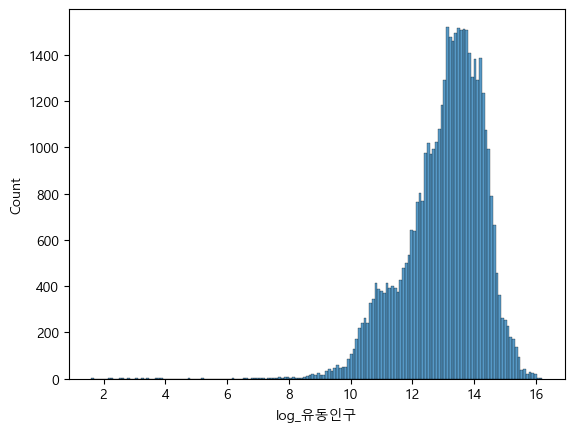

In [53]:
sns.histplot(df['log_유동인구'])

In [54]:
df.groupby('상권_구분_코드_명')['log_유동인구'].mean()

상권_구분_코드_명
골목상권    13.172030
관광특구    14.672515
발달상권    13.683593
전통시장    12.061374
Name: log_유동인구, dtype: float64

## 상권 유형별 성별 유동인구 비율
### 유동 비율이 여성이 남성보다 많음 확인 

In [55]:
# 상권 유형별 성별 비율 평균
df['남성_비율'] = df['남성_유동인구_수'] / df['총_유동인구_수'] * 100
df['여성_비율'] = df['여성_유동인구_수'] / df['총_유동인구_수'] * 100
gender_by_type = df.groupby('상권_구분_코드_명')[['남성_비율','여성_비율']].mean()
gender_by_type.round(1)

,남성_비율,여성_비율
상권_구분_코드_명,,
골목상권,47.3,52.7
관광특구,49.8,50.2
발달상권,48.8,51.2
전통시장,47.6,52.4


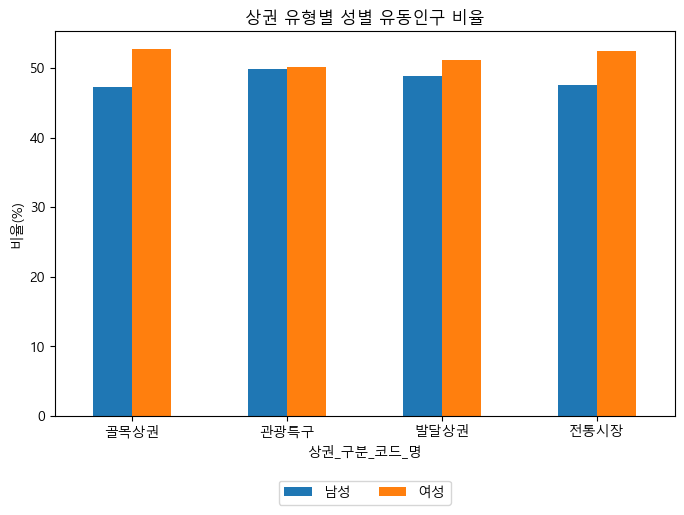

In [56]:
df['남성_비율'] = df['남성_유동인구_수'] / df['총_유동인구_수'] * 100
df['여성_비율'] = df['여성_유동인구_수'] / df['총_유동인구_수'] * 100

age_cols = ['연령대_10','연령대_20','연령대_30','연령대_40','연령대_50','연령대_60_이상']

for col in age_cols:
    df[f'{col}_비율'] = df[f'{col}_유동인구_수'] / df['총_유동인구_수'] * 100

# 상권 유형별 성별 비율 평균
gender_by_type = df.groupby('상권_구분_코드_명')[['남성_비율','여성_비율']].mean()

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

gender_by_type.plot(kind='bar', figsize=(8,5))

plt.title('상권 유형별 성별 유동인구 비율')
plt.ylabel('비율(%)')
plt.xticks(rotation=0)
plt.legend(['남성','여성'],
           loc='upper center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=2)
plt.show()

In [83]:
gender_year = df.groupby(['기준_년', '상권_구분_코드_명'])[['남성_비율', '여성_비율']].mean()
gender_year.round(1)

남성_비율  여성_비율
기준_년 상권_구분_코드_명              
2019 골목상권         47.2   52.8
     관광특구         49.3   50.7
     발달상권         48.8   51.2
     전통시장         47.4   52.6
2020 골목상권         47.4   52.6
     관광특구         51.0   49.0
     발달상권         49.4   50.6
     전통시장         47.8   52.2
2021 골목상권         47.5   52.5
     관광특구         50.4   49.6
     발달상권         49.3   50.7
     전통시장         47.8   52.2
2022 골목상권         47.5   52.5
     관광특구         49.8   50.2
     발달상권         49.0   51.0
     전통시장         47.8   52.2
2023 골목상권         47.4   52.6
     관광특구         49.5   50.5
     발달상권         48.7   51.3
     전통시장         47.6   52.4
2024 골목상권         47.2   52.8
     관광특구         49.3   50.7
     발달상권         48.5   51.5
     전통시장         47.5   52.5
2025 골목상권         47.2   52.8
     관광특구         49.2   50.8
     발달상권         48.2   51.8
     전통시장         47.3   52.7

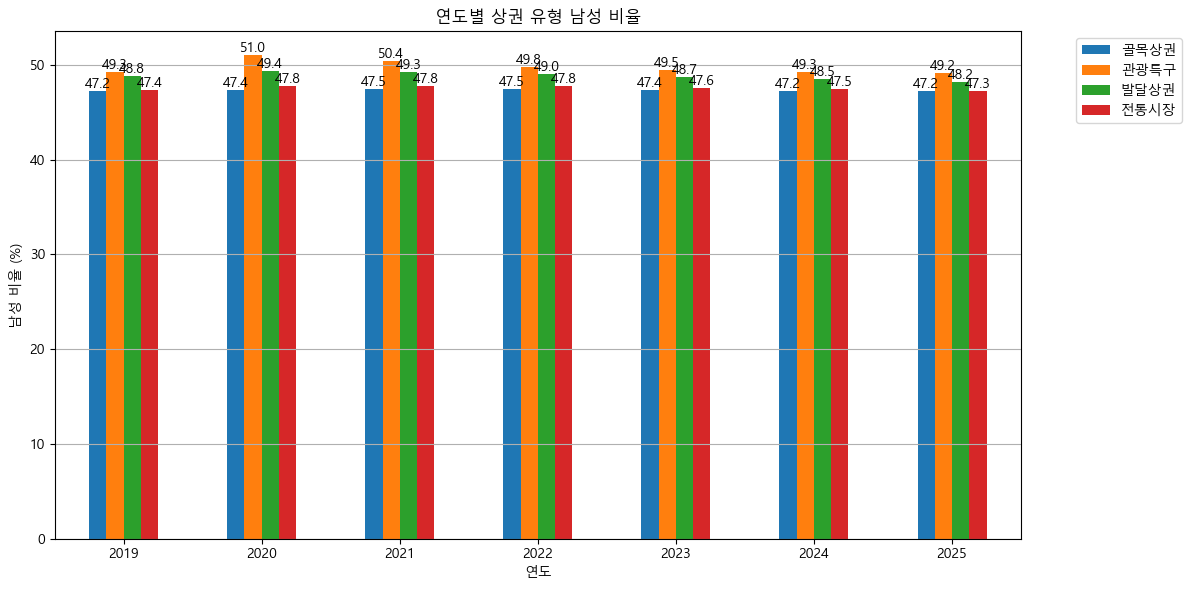

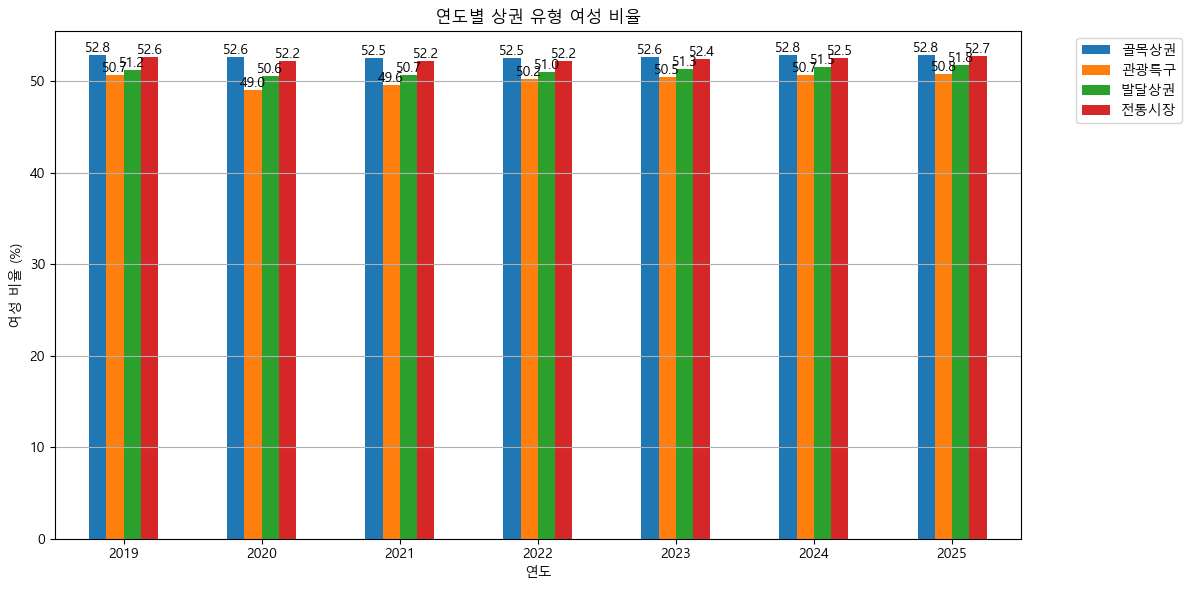

In [86]:
import matplotlib.pyplot as plt

# 데이터 준비
gender_year = df.groupby(['기준_년', '상권_구분_코드_명'])[['남성_비율', '여성_비율']].mean().round(1)

male = gender_year['남성_비율'].unstack()
female = gender_year['여성_비율'].unstack()

# 남성
ax = male.plot(kind='bar', figsize=(12,6))
plt.title('연도별 상권 유형 남성 비율')
plt.ylabel('남성 비율 (%)')
plt.xlabel('연도')
plt.xticks(rotation=0)
plt.grid(axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()  


plt.show()

# 여성
ax = female.plot(kind='bar', figsize=(12,6))
plt.title('연도별 상권 유형 여성 비율')
plt.ylabel('여성 비율 (%)')
plt.xlabel('연도')
plt.xticks(rotation=0)
plt.grid(axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.tight_layout()  

plt.show()

### 상권 유형별 분기별 평균 유동인구 추세

In [57]:
# 20211 → 연도 2021, 분기 1
df['연도'] = df['기준_년분기_코드'] // 10
df['분기'] = df['기준_년분기_코드'] % 10

# 시각화·정렬용 문자열 레이블
df['년분기'] = df['연도'].astype(str) + '-Q' + df['분기'].astype(str)

# pandas Period로 변환 (시계열 연산에 유리)
df['period'] = pd.PeriodIndex(
    df['연도'].astype(str) + 'Q' + df['분기'].astype(str), freq='Q'
)

# 정렬 확인
print(sorted(df['년분기'].unique()))
# ['2021-Q1', '2021-Q2', ..., '2023-Q4']

['2019-Q1', '2019-Q2', '2019-Q3', '2019-Q4', '2020-Q1', '2020-Q2', '2020-Q3', '2020-Q4', '2021-Q1', '2021-Q2', '2021-Q3', '2021-Q4', '2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']


In [58]:
df['연도'] = df['기준_년분기_코드'] // 10
df['분기'] = df['기준_년분기_코드'] % 10

df['년분기'] = df['연도'].astype(str) + '-Q' + df['분기'].astype(str)

ts = df.groupby(['년분기', '상권_구분_코드_명'])['총_유동인구_수'].mean().reset_index()

In [59]:
ts['연도'] = ts['년분기'].str.split('-').str[0]
ts['분기'] = ts['년분기'].str.split('-').str[1]

pivot = ts.pivot_table(
    index='연도',
    columns=['분기', '상권_구분_코드_명'],
    values='총_유동인구_수'
)

pivot.round(0)

분기                Q1                                        Q2             \
상권_구분_코드_명      골목상권       관광특구       발달상권      전통시장      골목상권       관광특구   
연도                                                                          
2019        899696.0  4825955.0  1418356.0  380888.0  870249.0  4859104.0   
2020        908899.0  4050275.0  1334513.0  360751.0  888101.0  3897843.0   
2021        871092.0  3577983.0  1234560.0  336118.0  859493.0  3862273.0   
2022        854422.0  3770117.0  1267549.0  333437.0  854022.0  4324220.0   
2023        844023.0  4250058.0  1342222.0  332433.0  832513.0  4274127.0   
2024        835026.0  4181643.0  1349654.0  331334.0  818653.0  4269076.0   
2025        813123.0  4108186.0  1318980.0  315959.0  805442.0  4214331.0   

분기                                     Q3                                  \
상권_구분_코드_명       발달상권      전통시장      골목상권       관광특구       발달상권      전통시장   
연도                                                                          
2019        1387027.0  368759.0  862438.0  4778958.0  1406892.0  367953.0   
2020        1301306.0  348450.0  876675.0  3748308.0  1274831.0  341120.0   
2021        1274144.0  337559.0  848850.0  3575066.0  1225207.0  324233.0   
2022        1353636.0  341528.0  833831.0  4192285.0  1324382.0  329590.0   
2023        1341926.0  330043.0  822906.0  4102975.0  1325332.0  326603.0   
2024        1347293.0  325567.0  808381.0  4109657.0  1321903.0  317916.0   
2025        1322212.0  313387.0  797044.0  4149750.0  1331799.0  308282.0   

분기                Q4                                  
상권_구분_코드_명      골목상권       관광특구       발달상권      전통시장  
연도                                                    
2019        893279.0  4853660.0  1426927.0  375144.0  
2020        869884.0  3697580.0  1243494.0  336500.0  
2021        847330.0  4028129.0  1294101.0  333541.0  
2022        838770.0  4360238.0  1342150.0  332721.0  
2023        832929.0  4309986.0  1353549.0  331915.0  
2024        814577.0  4339048.0  1340554.0  320720.0  
2025        793367.0  4249076.0  1317609.0  308355.0

<Figure size 1200x600 with 0 Axes>

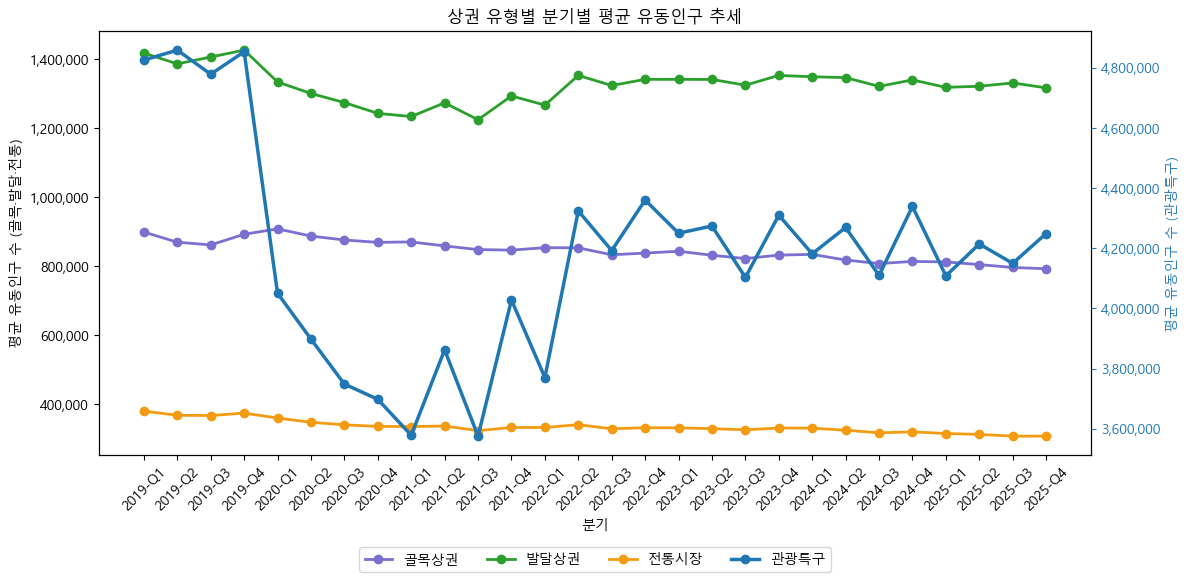

In [60]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()  # 오른쪽 축

# 색상 (가독성 좋게)
colors = {
    '골목상권': '#7b6fd0',
    '발달상권': '#2ca02c',
    '전통시장': '#f39c12',
    '관광특구': '#1f77b4'
}

for name, grp in ts.groupby('상권_구분_코드_명'):
    
    if name == '관광특구':
        ax2.plot(grp['년분기'], grp['총_유동인구_수'],
                 marker='o', linewidth=2.5,
                 color=colors[name], label=name)
    else:
        ax1.plot(grp['년분기'], grp['총_유동인구_수'],
                 marker='o', linewidth=2,
                 color=colors[name], label=name)

# 축 설정
ax1.set_xlabel('분기')
ax1.set_ylabel('평균 유동인구 수 (골목·발달·전통)')
ax2.set_ylabel('평균 유동인구 수 (관광특구)', color=colors['관광특구'])

# x축 회전
ax1.tick_params(axis='x', rotation=45)

# y축 색상 맞추기
ax2.tick_params(axis='y', colors=colors['관광특구'])

# 숫자 포맷 (천 단위 콤마)
import matplotlib.ticker as mticker
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.2),
           ncol=4)

plt.title('상권 유형별 분기별 평균 유동인구 추세')

plt.tight_layout()
plt.show()

### 연도별 상권 유형 평균 유동인구 변화

In [61]:
# 기준 - 년도 분리 
df['기준_년'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
df['기준_분기'] = df['기준_년분기_코드'].astype(str).str[-1].astype(int)

In [62]:
df.groupby('기준_년')['총_유동인구_수'].mean()

기준_년
2019    881564.414091
2020    857758.503788
2021    830833.885000
2022    834807.023791
2023    829118.857013
2024    818571.045186
2025    802351.670811
Name: 총_유동인구_수, dtype: float64

In [63]:
df.groupby(['기준_년', '상권_구분_코드_명'])['총_유동인구_수'].mean()

기준_년  상권_구분_코드_명
2019  골목상권          8.814154e+05
      관광특구          4.829419e+06
      발달상권          1.409800e+06
      전통시장          3.731859e+05
2020  골목상권          8.858898e+05
      관광특구          3.848502e+06
      발달상권          1.288536e+06
      전통시장          3.467053e+05
2021  골목상권          8.566916e+05
      관광특구          3.760863e+06
      발달상권          1.257003e+06
      전통시장          3.328627e+05
2022  골목상권          8.452627e+05
      관광특구          4.161715e+06
      발달상권          1.321929e+06
      전통시장          3.343187e+05
2023  골목상권          8.330927e+05
      관광특구          4.234286e+06
      발달상권          1.340757e+06
      전통시장          3.302484e+05
2024  골목상권          8.191617e+05
      관광특구          4.224856e+06
      발달상권          1.339851e+06
      전통시장          3.238842e+05
2025  골목상권          8.022496e+05
      관광특구          4.180336e+06
      발달상권          1.322650e+06
      전통시장          3.114957e+05
Name: 총_유동인구_수, dtype: float64

In [64]:
table = df.groupby(['기준_년', '상권_구분_코드_명'])['총_유동인구_수'].mean().unstack()
table.round(1)

상권_구분_코드_명,골목상권,관광특구,발달상권,전통시장
기준_년,,,,
2019,881415.4,4829419.4,1409800.4,373185.9
2020,885889.8,3848501.7,1288536.3,346705.3
2021,856691.6,3760862.6,1257003.1,332862.7
2022,845262.7,4161715.2,1321929.2,334318.7
2023,833092.7,4234286.5,1340757.1,330248.4
2024,819161.7,4224856.1,1339851.1,323884.2
2025,802249.6,4180335.8,1322649.9,311495.7


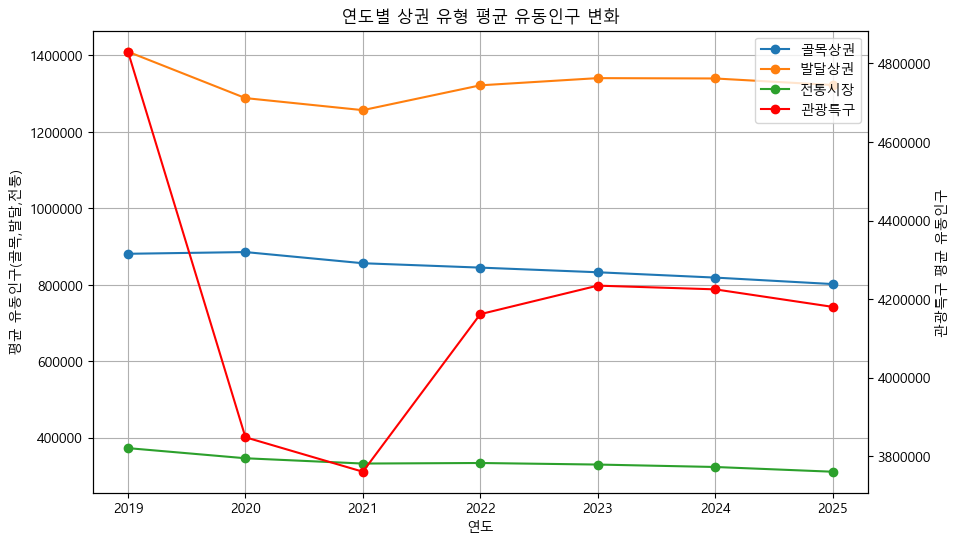

In [65]:
import matplotlib.pyplot as plt

# 집계
grouped = df.groupby(['기준_년', '상권_구분_코드_명'])['총_유동인구_수'].mean().unstack()

# 그래프
fig, ax1 = plt.subplots(figsize=(10, 6))

# 왼쪽 y축 (골목, 발달, 전통시장)
for col in grouped.columns:
    if col != '관광특구':
        ax1.plot(grouped.index, grouped[col], marker='o', label=col)

ax1.set_xlabel('연도')
ax1.set_ylabel('평균 유동인구(골목,발달,전통)')
ax1.grid(True)

# 오른쪽 y축 (관광특구)
ax2 = ax1.twinx()
ax2.plot(grouped.index, grouped['관광특구'], marker='o', color='red', label='관광특구')

ax2.set_ylabel('관광특구 평균 유동인구')

# 범례 합치기
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
ax1.ticklabel_format(style='plain', axis='y')
ax2.ticklabel_format(style='plain', axis='y')

plt.title('연도별 상권 유형 평균 유동인구 변화')
plt.show()

# 상권 유형별 시간대 유동인구 비율

### 골목상권 — 심야형
### 25.5%로 전체 상권 중 1위 → 심야 유흥·음식점 업종이 구조적으로 많다

### 관광특구
### 외국인 관광객은 특정 시간에 몰리지 않고 낮 내내 분산 방문

### 발달상권 - 직장인 루트
### 출근길 방문과 퇴근 후

### 전통시장 - 새벽·오전형
### 00~06시(21.7%)가 골목상권 다음으로 높음 
### → 새벽 도매·납품 상인의 이동 인구가 반영

In [66]:
# 1. 시간대 비율 컬럼
time_cols = [
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수'
]

time_labels = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']

for col, label in zip(time_cols, time_labels):
    df[label] = df[col] / df['총_유동인구_수'] * 100

# 2. 상권 유형별 평균
grouped = df.groupby('상권_구분_코드_명')[time_labels].mean()
grouped.round(1)

,00~06시,06~11시,11~14시,14~17시,17~21시,21~24시
상권_구분_코드_명,,,,,,
골목상권,25.5,20.8,12.3,12.2,16.6,12.6
관광특구,13.4,19.1,18.9,19.4,20.0,9.2
발달상권,17.3,20.2,16.0,16.4,19.4,10.7
전통시장,21.7,19.7,13.7,14.2,18.6,12.2


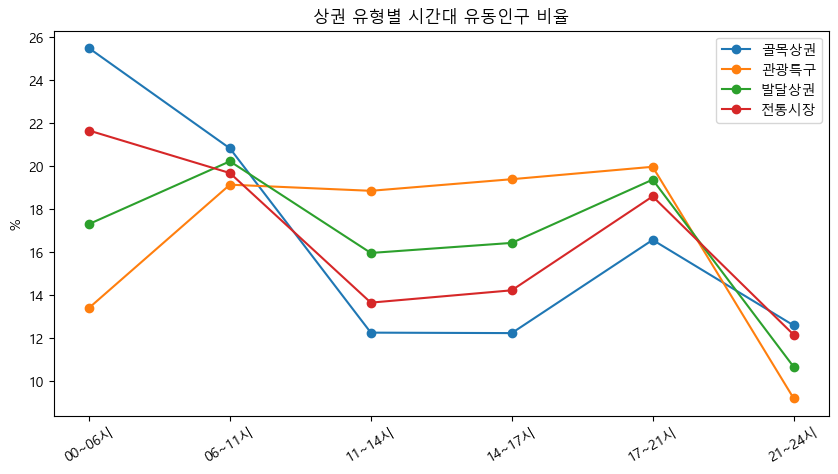

In [67]:
# 1. 시간대 비율 컬럼
time_cols = [
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수'
]

time_labels = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']

for col, label in zip(time_cols, time_labels):
    df[label] = df[col] / df['총_유동인구_수'] * 100

# 2. 상권 유형별 평균
grouped = df.groupby('상권_구분_코드_명')[time_labels].mean()

# 3. 그래프
fig, ax = plt.subplots(figsize=(10, 5))

for name, row in grouped.iterrows():
    ax.plot(time_labels, row, marker='o', label=name)

ax.set_title('상권 유형별 시간대 유동인구 비율')
ax.set_ylabel('%')
ax.legend()
plt.xticks(rotation=30)
plt.show()

# 유동인구 Top 20 상권

### 상위

In [109]:
# 상권 간 비교 분석
# Top N 상권 랭킹
import matplotlib.font_manager as fm

# 한글 폰트 설정 (환경에 맞게 조정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [110]:
df['상권_코드_명'] = df['상권_코드_명'].str.replace('?', '·', regex=False)

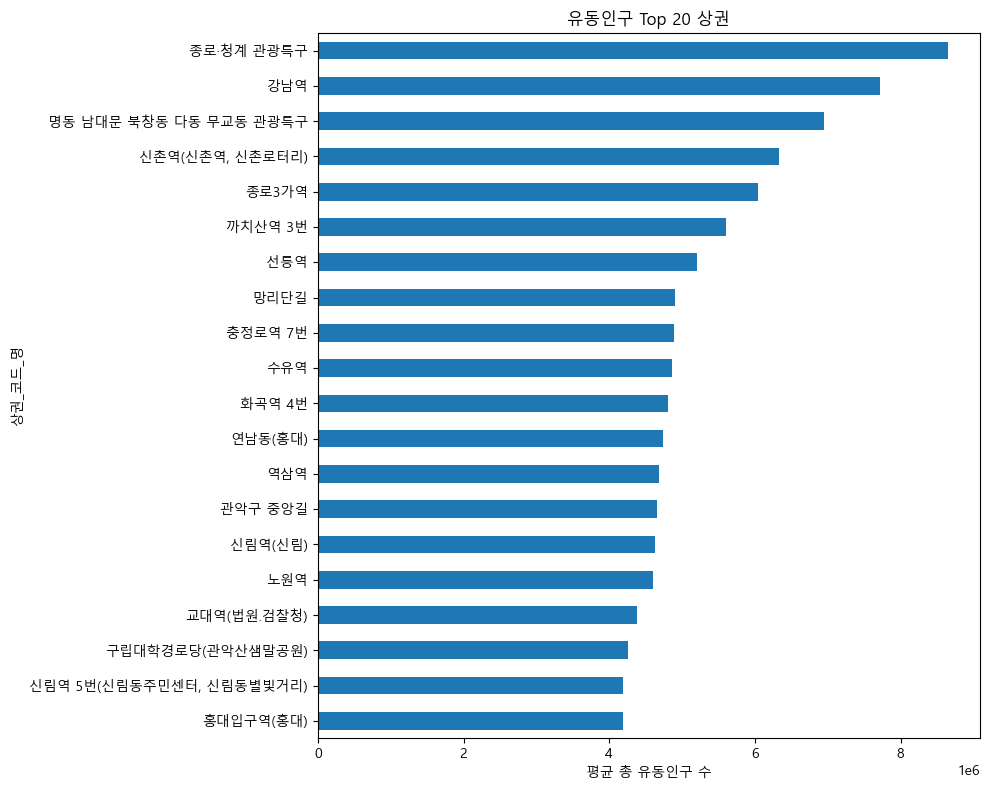

In [111]:
# 상권별 평균 유동인구 (분기 여러 개 있으므로 평균 사용)
top_n = (df.groupby('상권_코드_명')['총_유동인구_수']
           .mean()
           .sort_values(ascending=False)
           .head(20))

top_n.sort_values().plot(kind='barh', figsize=(10, 8))
plt.xlabel('평균 총 유동인구 수')
plt.title('유동인구 Top 20 상권')
plt.tight_layout()
plt.show()

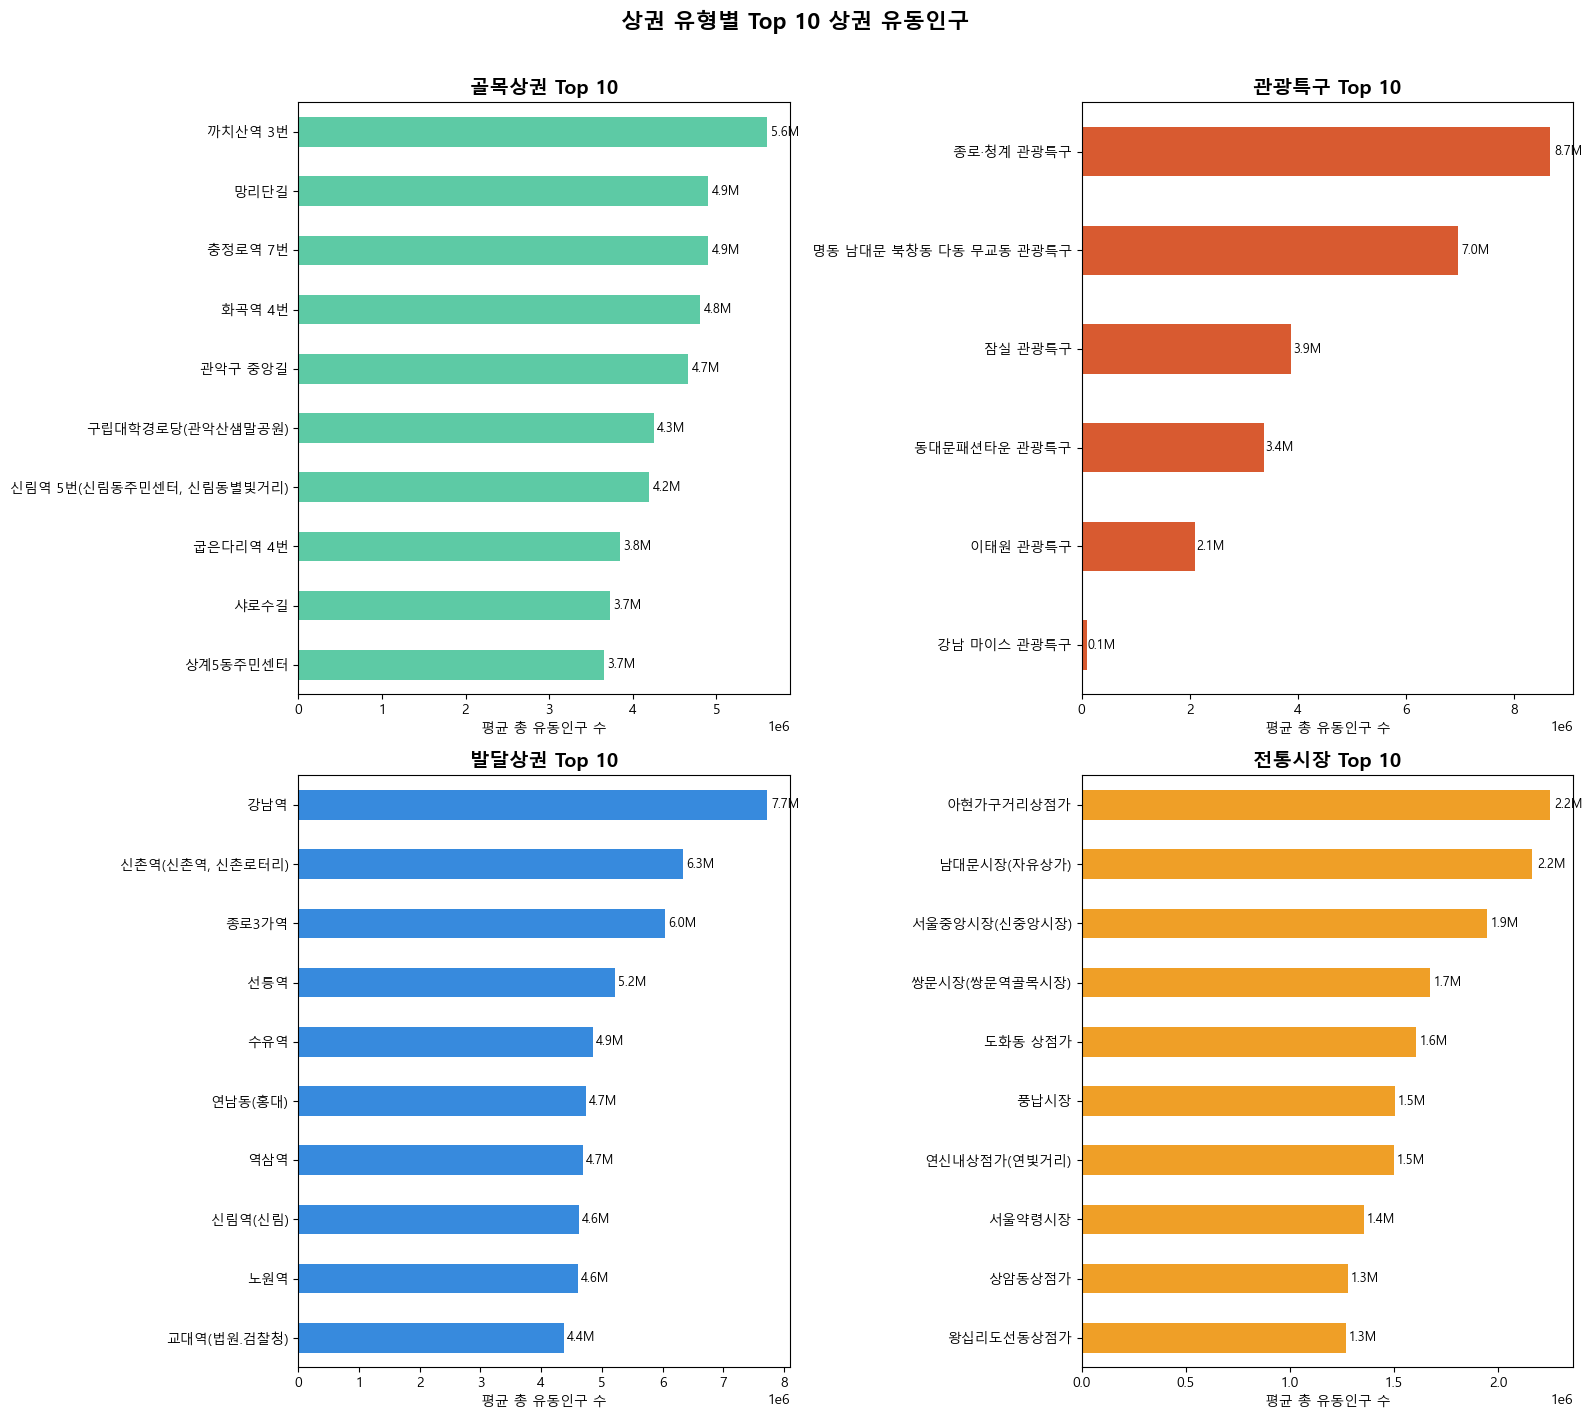

In [112]:
types = df['상권_구분_코드_명'].unique()

color_dict = {
    '골목상권':  '#5DCAA5',
    '발달상권':  '#378ADD',
    '관광특구':  '#D85A30',
    '전통시장':  '#EF9F27'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, t in enumerate(sorted(types)):
    top = (df[df['상권_구분_코드_명'] == t]
             .groupby('상권_코드_명')['총_유동인구_수']
             .mean()
             .sort_values(ascending=False)
             .head(10)
             .sort_values()) 

    color = color_dict.get(t, '#888')
    top.plot(kind='barh', ax=axes[i], color=color)
    axes[i].set_title(f'{t} Top 10', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('평균 총 유동인구 수')
    axes[i].set_ylabel('')

        # 막대 끝에 값 표시
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width()/1e6:.1f}M',
            va='center', fontsize=9
        )

plt.suptitle('상권 유형별 Top 10 상권 유동인구', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 하위

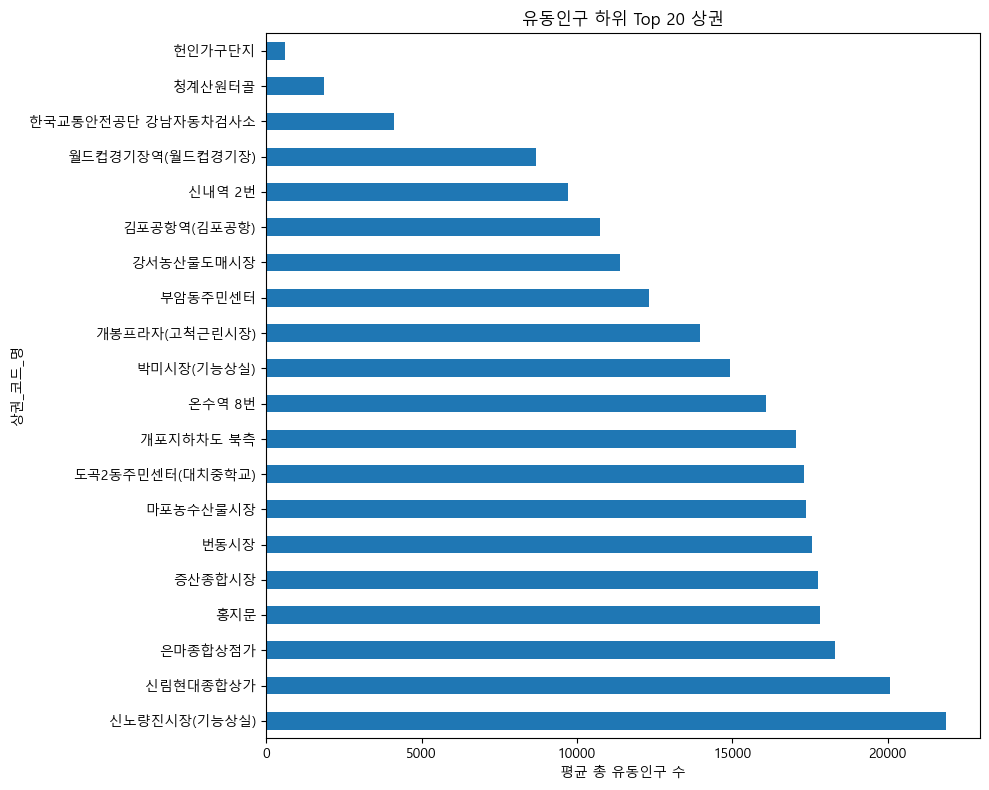

In [113]:
# 상권별 평균 유동인구 (분기 여러 개 있으므로 평균 사용)
top_n = (df.groupby('상권_코드_명')['총_유동인구_수']
           .mean()
           .sort_values(ascending=True)
           .head(20))

top_n.sort_values(ascending=False).plot(kind='barh', figsize=(10, 8))
plt.xlabel('평균 총 유동인구 수')
plt.title('유동인구 하위 Top 20 상권')
plt.tight_layout()
plt.show()

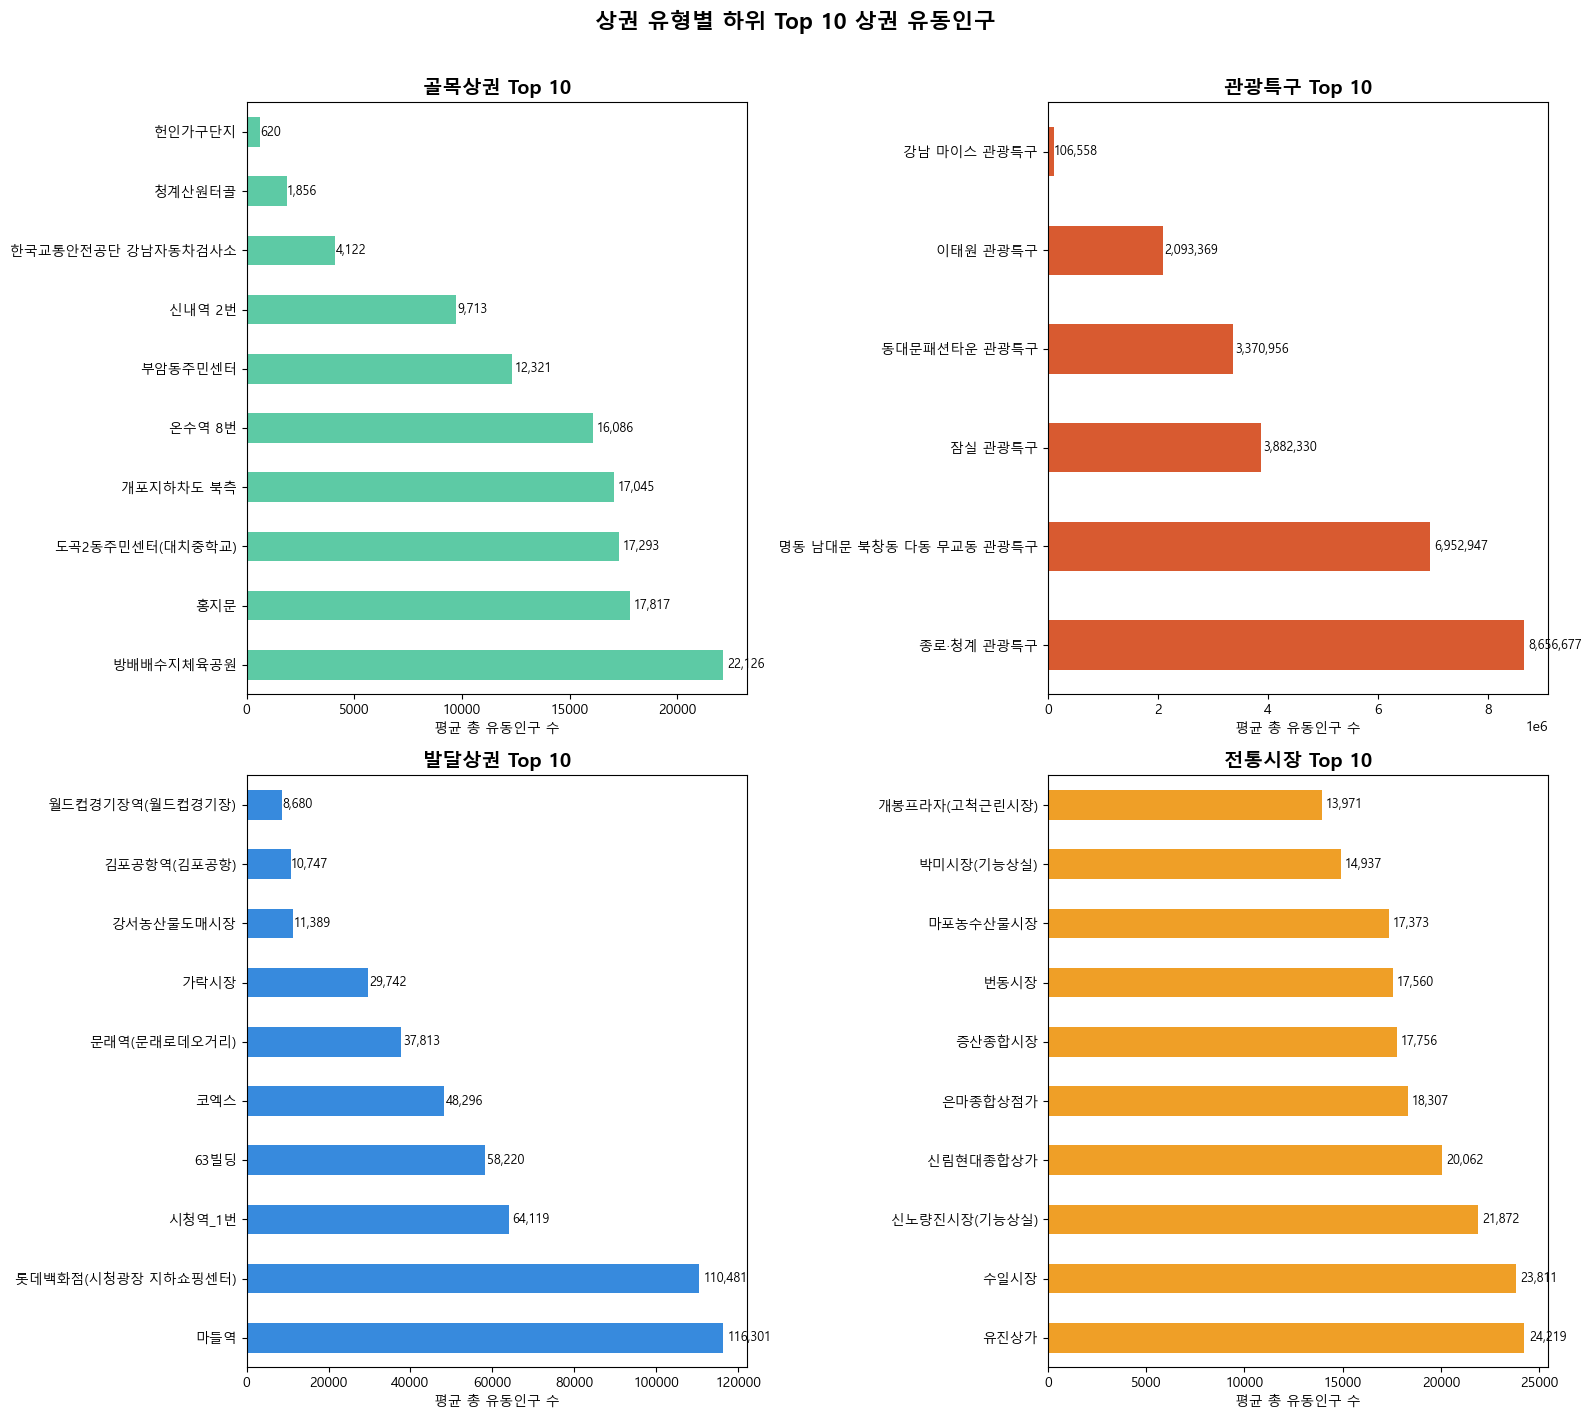

In [115]:
types = df['상권_구분_코드_명'].unique()

color_dict = {
    '골목상권':  '#5DCAA5',
    '발달상권':  '#378ADD',
    '관광특구':  '#D85A30',
    '전통시장':  '#EF9F27'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, t in enumerate(sorted(types)):
    top = (df[df['상권_구분_코드_명'] == t]
             .groupby('상권_코드_명')['총_유동인구_수']
             .mean()
             .sort_values(ascending=True)
             .head(10)
             .sort_values(ascending=False)) 

    color = color_dict.get(t, '#888')
    top.plot(kind='barh', ax=axes[i], color=color)
    axes[i].set_title(f'{t} Top 10', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('평균 총 유동인구 수')
    axes[i].set_ylabel('')

        # 막대 끝에 값 표시
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f}',
            va='center', fontsize=9
        )

plt.suptitle('상권 유형별 하위 Top 10 상권 유동인구', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [88]:
df.groupby(['상권_구분_코드_명', '상권_코드_명'])['총_유동인구_수'].mean().sort_values().head(20)

상권_구분_코드_명  상권_코드_명          
골목상권        헌인가구단지                 620.269231
            청계산원터골                1856.235294
            한국교통안전공단 강남자동차검사소     4122.080000
발달상권        월드컵경기장역(월드컵경기장)       8680.035714
골목상권        신내역 2번                9713.285714
발달상권        김포공항역(김포공항)          10747.107143
            강서농산물도매시장            11389.000000
골목상권        부암동주민센터              12321.250000
전통시장        개봉프라자(고척근린시장)        13971.392857
            박미시장(기능상실)           14937.392857
골목상권        온수역 8번               16086.321429
            개포지하차도 북측            17045.464286
            도곡2동주민센터(대치중학교)      17293.178571
전통시장        마포농수산물시장             17372.607143
            번동시장                 17560.178571
            증산종합시장               17756.035714
골목상권        홍지문                  17817.392857
전통시장        은마종합상점가              18306.928571
            신림현대종합상가             20061.714286
            신노량진시장(기능상실)         21872.035714
Name: 총_유동인구_수, dtype: float64

### 상권 유형별 x 요일별 유동인구 비율

In [71]:
day_cols = [
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수'
]

day_labels = ['월', '화', '수', '목', '금', '토', '일']

for col, label in zip(day_cols, day_labels):
    df[label] = df[col] / df['총_유동인구_수'] * 100

grouped = df.groupby('상권_구분_코드_명')[day_labels].mean()
grouped.round(1)

,월,화,수,목,금,토,일
상권_구분_코드_명,,,,,,,
골목상권,14.3,14.3,14.3,14.3,14.2,14.2,14.3
관광특구,14.6,15.1,15.3,15.5,15.5,13.0,11.1
발달상권,14.7,15.0,15.0,15.0,15.0,13.2,12.2
전통시장,14.3,14.3,14.4,14.4,14.4,14.3,13.9


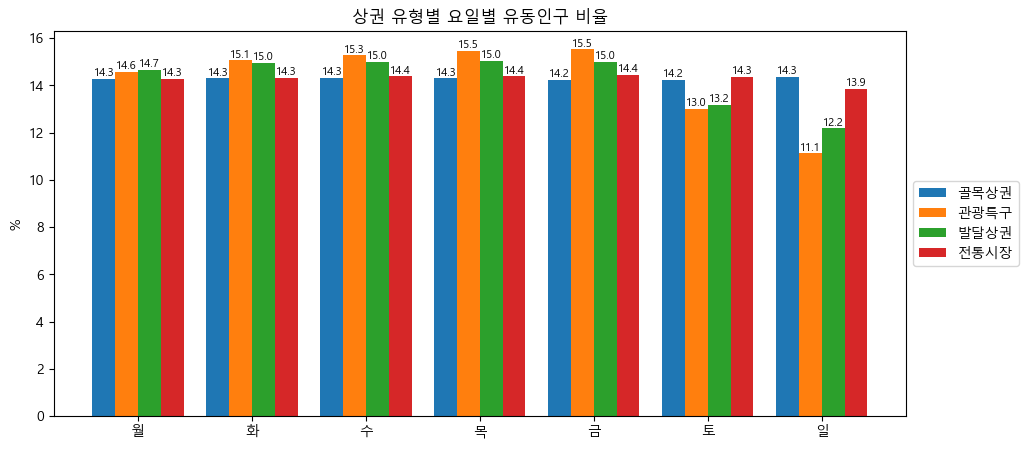

In [72]:
# 1. 요일 비율 생성
day_cols = [
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수'
]

day_labels = ['월', '화', '수', '목', '금', '토', '일']

for col, label in zip(day_cols, day_labels):
    df[label] = df[col] / df['총_유동인구_수'] * 100

# 2. 상권별 평균
grouped = df.groupby('상권_구분_코드_명')[day_labels].mean()

# 3. 그래프
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(day_labels))

for i, (name, row) in enumerate(grouped.iterrows()):
    bars = ax.bar(x + i*0.2, row, width=0.2, label=name)

    # 👉 막대 위에 값 표시
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1f}',
            ha='center',
            va='bottom',
            fontsize=8
        )


ax.set_xticks(x + 0.3)
ax.set_xticklabels(day_labels)
ax.set_title('상권 유형별 요일별 유동인구 비율')
ax.set_ylabel('%')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# 코로나 시기 비교 

### 관광특구 - 가장 크게 떨어지고, 가장 많이 회복
### 엔데믹 구간에서 회복했지만 코로나 후에 감소하는 현상 발견 → . 외국인 관광객 회복이 기대에 못 미쳤거나, 사회적 이슈나로 인해 이미지 타격

### 골목상권
### 골목상권 자체의 구조적 감소(꼭 코로나의 문제는 아닌걸로 보임) → 온라인 소비 전환, 대형몰 집중화 영향

### 발달상권
### 엔데믹 이후 회복이 거의 stop
### → 직장인 유동인구가 줄어든 영향

### 전통시장
### 전반적으로 비중이 가장 작음

In [73]:
# 코로나 구간 매핑 함수
def covid_label(code):
    if 20191 <= code <= 20194:
        return '코로나 전'
    elif 20201 <= code <= 20223:
        return '코로나 집중'
    elif 20224 <= code <= 20232:
        return '엔데믹'
    elif 20233 <= code <= 20254:
        return '코로나 후'
    else:
        return '기타'

df['코로나_구간'] = df['기준_년분기_코드'].apply(covid_label)

# 구간 순서 고정 (그래프 정렬용)
covid_order = ['코로나 전', '코로나 집중', '엔데믹', '코로나 후']
df['코로나_구간'] = pd.Categorical(df['코로나_구간'],
                                    categories=covid_order, ordered=True)

# 구간 × 상권 유형별 평균 유동인구
covid_by_type = (df.groupby(['코로나_구간', '상권_구분_코드_명'])['총_유동인구_수']
                    .mean()
                    .unstack('상권_구분_코드_명'))

# print(covid_by_type.map(lambda x: f'{x:,.0f}'))
covid_by_type.style.format("{:,.0f}")

C:\Users\augo7\AppData\Local\Temp\ipykernel_23840\3968465958.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  covid_by_type = (df.groupby(['코로나_구간', '상권_구분_코드_명'])['총_유동인구_수']


상권_구분_코드_명,골목상권,관광특구,발달상권,전통시장
코로나_구간,,,,
코로나 전,"881,415","4,829,419","1,409,800","373,186"
코로나 집중,"864,782","3,884,007","1,284,339","338,439"
엔데믹,"838,435","4,294,808","1,342,099","331,732"
코로나 후,"814,147","4,203,373","1,332,888","320,004"


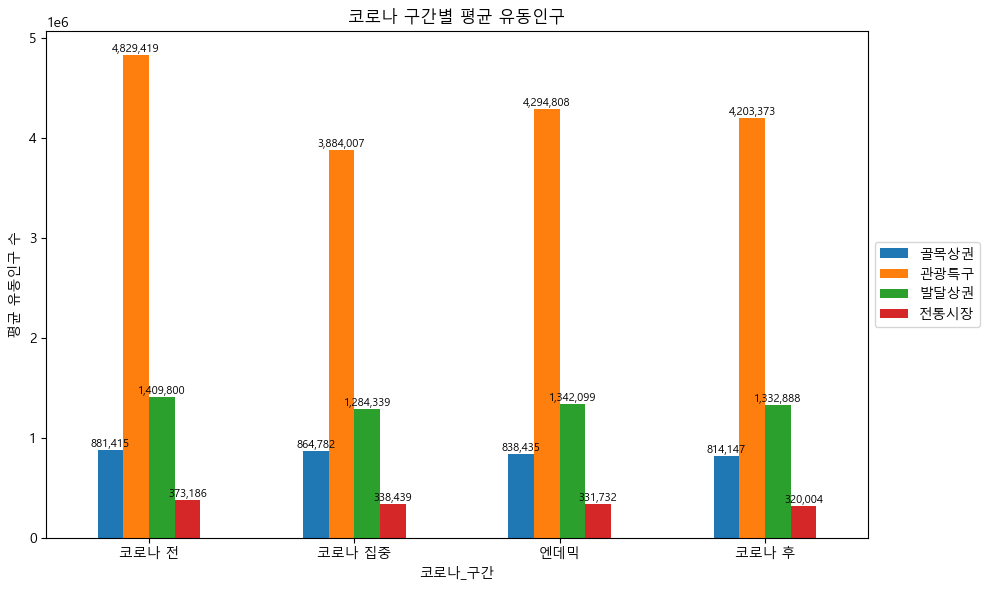

In [74]:
# 1. 코로나 구간 만들기
def covid_label(code):
    if 20191 <= code <= 20194:
        return '코로나 전'
    elif 20201 <= code <= 20223:
        return '코로나 집중'
    elif 20224 <= code <= 20232:
        return '엔데믹'
    elif 20233 <= code <= 20254:
        return '코로나 후'

df['코로나_구간'] = df['기준_년분기_코드'].apply(covid_label)
covid_order = ['코로나 전', '코로나 집중', '엔데믹', '코로나 후']

# 2. 상권별 평균
grouped = df.groupby(['코로나_구간', '상권_구분_코드_명'])['총_유동인구_수'].mean().unstack()
grouped = grouped.reindex(covid_order)

# 3. 그래프
ax = grouped.plot(kind='bar', figsize=(10, 6))
plt.title('코로나 구간별 평균 유동인구')
plt.xticks(rotation=0)
plt.ylabel('평균 유동인구 수')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', fontsize=8)

plt.tight_layout()
plt.show()